# NOAA Weather Time-Series Case Study — Bengaluru (VOBL)
**Global Summary of the Day (GSOD)** · Station `43295099999` · 2010–2024 (≈15 years)

Daily temperature & precipitation: trend, seasonality, stationarity, ACF/PACF, and
short-term forecasting with five baselines, an LSTM, and a Transformer — evaluated at
one step and across a 30-day horizon. Fully reproducible (seed = 42).

> Run `python src/run_analysis.py` once before executing this notebook so
> `results.json` and the figures in `figures/` are available.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import models as M, statistical_analysis as S
from preprocessing import build_processed
from IPython.display import Image, display
M.set_seed(42)
FIG = "../figures"
RES = json.load(open("../results.json"))   # metrics computed by run_analysis.py
pd.set_option("display.width", 120)

## 1. Research Problem
**How do temporal dependence, trend, and seasonal patterns influence daily mean
temperature at the Bengaluru NOAA station, and to what extent can historical
observations forecast temperature — one day ahead and across a 30-day horizon —
using LSTM and Transformer models?** Secondary: how does precipitation differ from
temperature in variability, stationarity, and autocorrelation?

Observational data — no causal claims. Primary variable: daily mean temperature (°C);
secondary: precipitation (mm). Objective: one-step (t+1) plus multi-horizon (t+1…t+30)
temperature forecasting. Time-series analysis is appropriate because the observations
are equally spaced, strongly autocorrelated, and carry an annual seasonal cycle.

## 2. Dataset Understanding
**GSOD** is NOAA/NCEI's quality-controlled daily surface archive (from the Integrated
Surface Database). Chosen because it is authoritative, free over HTTPS, genuinely
daily, small, and contains both temperature and precipitation. The **Bengaluru (VOBL)**
station offers a long continuous record with a clear monsoon-driven seasonal signal.

In [2]:
df = build_processed()
print("Shape:", df.shape, "| Date range:", df.index.min().date(), "->", df.index.max().date())
df.head()

Shape: (5479, 10) | Date range: 2010-01-01 -> 2024-12-31


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,temperature_c,tmax_c,tmin_c,precipitation_mm,temperature_c_interp
date,,,,,,,,,,
2010-01-01,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.055556,28.000000,17.888889,0.254,22.055556
2010-01-02,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.722222,28.500000,16.777778,NaN,21.722222
2010-01-03,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,20.777778,27.722222,16.777778,NaN,20.777778
2010-01-04,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.000000,29.000000,14.611111,NaN,21.000000
2010-01-05,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.277778,29.500000,15.388889,NaN,22.277778


In [3]:
df.tail()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,temperature_c,tmax_c,tmin_c,precipitation_mm,temperature_c_interp
date,,,,,,,,,,
2024-12-27,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.277778,24.722222,19.277778,1.016,21.277778
2024-12-28,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.055556,26.222222,17.888889,NaN,22.055556
2024-12-29,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.444444,27.388889,17.388889,NaN,22.444444
2024-12-30,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.888889,28.222222,17.777778,NaN,21.888889
2024-12-31,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,23.055556,28.611111,16.611111,NaN,23.055556


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5479 entries, 2010-01-01 to 2024-12-31
Freq: D
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   STATION               5479 non-null   float64
 1   NAME                  5479 non-null   object 
 2   LATITUDE              5479 non-null   float64
 3   LONGITUDE             5479 non-null   float64
 4   ELEVATION             5479 non-null   float64
 5   temperature_c         5452 non-null   float64
 6   tmax_c                5452 non-null   float64
 7   tmin_c                5452 non-null   float64
 8   precipitation_mm      2885 non-null   float64
 9   temperature_c_interp  5479 non-null   float64
dtypes: float64(9), object(1)
memory usage: 470.9+ KB


In [5]:
print("Station:", df['NAME'].iloc[0], "| id 43295099999 |",
      df['LATITUDE'].iloc[0], df['LONGITUDE'].iloc[0], "| elev", df['ELEVATION'].iloc[0], "m")
df[['temperature_c','tmax_c','tmin_c','precipitation_mm']].describe()

Station: BANGALORE, IN | id 43295099999 | 12.9666666 77.5833333 | elev 921.0 m


,temperature_c,tmax_c,tmin_c,precipitation_mm
count,5452.000000,5452.000000,5452.000000,2885.000000
mean,24.106750,30.198103,19.795355,6.095296
std,2.228548,2.905036,2.188503,13.487422
min,18.388889,19.777778,12.000000,0.000000
25%,22.500000,28.222222,18.611111,0.000000
50%,23.777778,29.722222,20.222222,0.508000
75%,25.388889,32.111111,21.000000,5.080000
max,31.611111,39.222222,25.777778,132.334000


In [6]:
print("Missing temperature_c :", int(df['temperature_c'].isna().sum()),
      "(interpolated into temperature_c_interp)")
print("Missing precipitation_mm:", int(df['precipitation_mm'].isna().sum()),
      "(dry-season 'I'-flag non-measurements kept as NaN)")
print("Duplicate dates:", int(df.index.duplicated().sum()))

Missing temperature_c : 27 (interpolated into temperature_c_interp)
Missing precipitation_mm: 2594 (dry-season 'I'-flag non-measurements kept as NaN)
Duplicate dates: 0


GSOD native units are °F (temperature, sentinel 9999.9) and inches (precipitation,
sentinel 99.99), converted to °C and mm. `PRCP` flag `I` means the day was **not
measured**, so those 0.00 values are treated as **missing**, not real zeros.
`temperature_c` keeps original missingness; `temperature_c_interp` fills ≤3-day gaps
for continuous-series methods. **Temperature is the forecast target** because it is
smooth, near-complete and strongly autocorrelated; precipitation is intermittent and
only weakly predictable day-to-day.

## 3. Data Cleaning and Preparation
Automated in `src/download_data.py` (HTTPS retrieval) and `src/preprocessing.py`:
date parsing, chronological sort, duplicate removal, reindex to a continuous daily
calendar, sentinel→NaN, `PRCP` flag semantics, °F→°C and inch→mm conversion, and
≤3-day time interpolation of temperature. Precipitation is **not** interpolated
(intermittent). No future data is used to fill the past; forecasting scalers are fit
on the training partition only.

In [7]:
temp = df['temperature_c_interp'].copy()
temp_raw = df['temperature_c'].copy()
prcp = df['precipitation_mm'].copy()

## 4. Time-Series Visualization

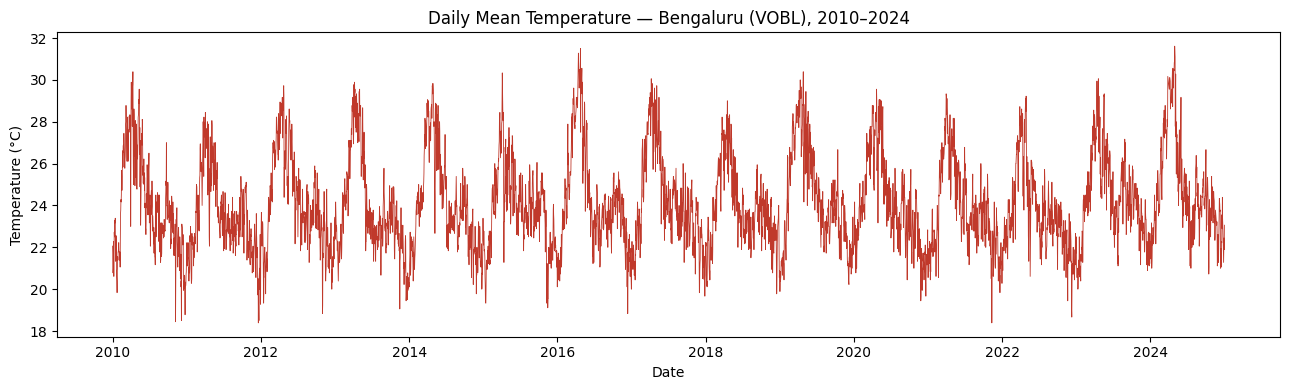

In [8]:
plt.figure(figsize=(13,4)); plt.plot(temp.index, temp.values, lw=0.6, color='#c0392b')
plt.title('Daily Mean Temperature — Bengaluru (VOBL), 2010–2024')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)'); plt.tight_layout(); plt.show()

*Clear repeating annual band ~18–32 °C; pre-monsoon (Mar–May) peaks, monsoon/winter troughs; no dramatic drift.*

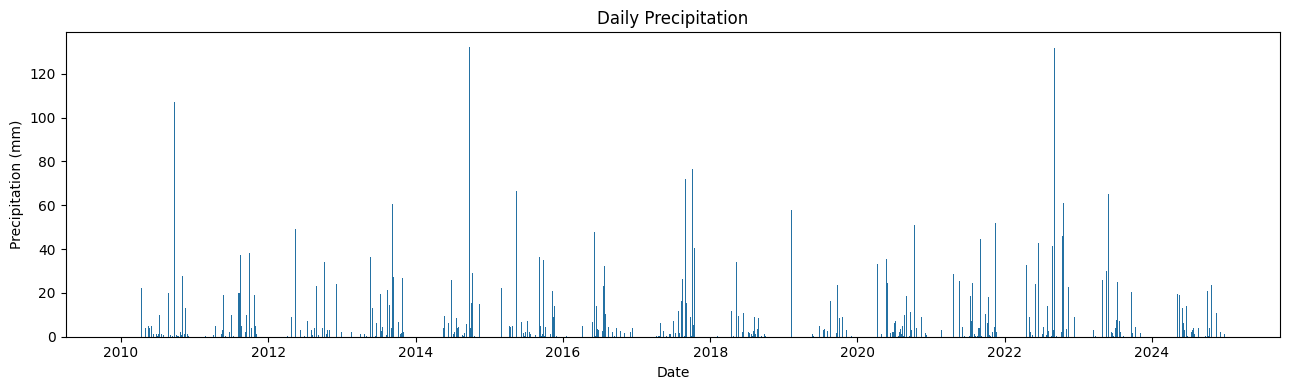

In [9]:
plt.figure(figsize=(13,4)); plt.bar(prcp.index, prcp.values, width=1.0, color='#2471a3')
plt.title('Daily Precipitation'); plt.xlabel('Date'); plt.ylabel('Precipitation (mm)'); plt.tight_layout(); plt.show()

*Spiky and intermittent: long near-zero dry stretches punctuated by clustered monsoon rainfall.*

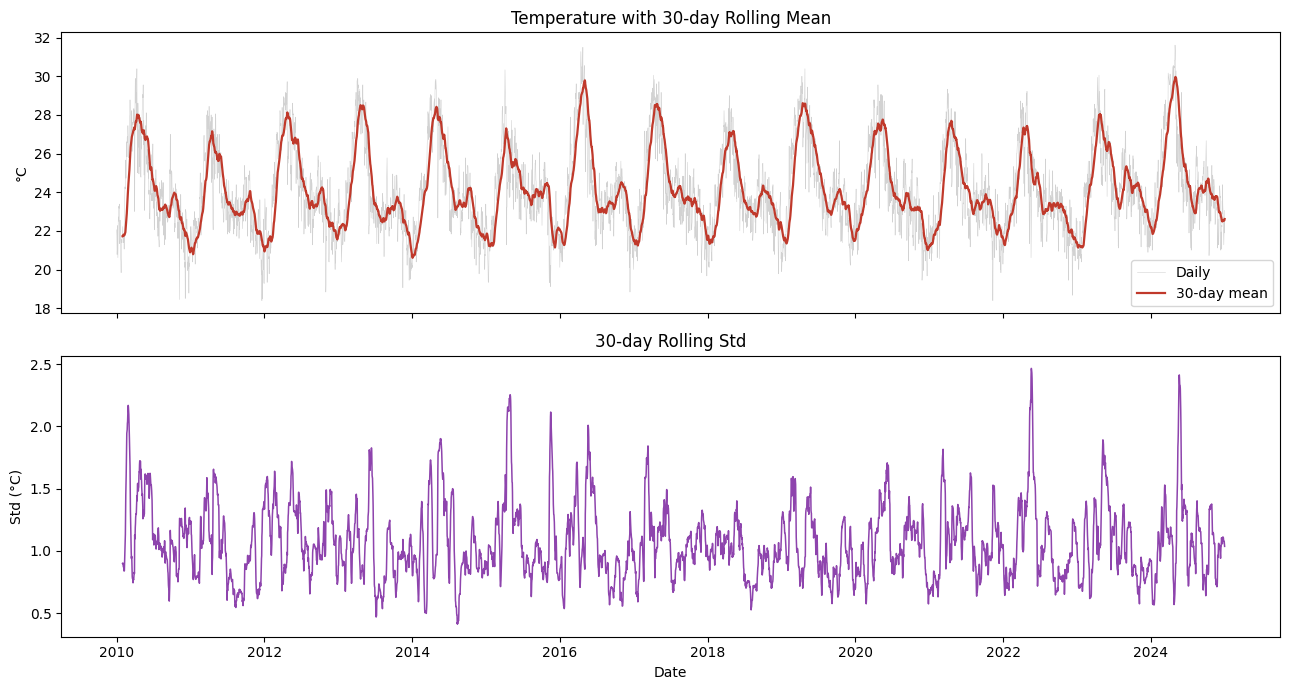

In [10]:
rm, rs = temp.rolling(30).mean(), temp.rolling(30).std()
fig, ax = plt.subplots(2,1,figsize=(13,7),sharex=True)
ax[0].plot(temp.index, temp.values, lw=0.4, alpha=0.35, color='grey', label='Daily')
ax[0].plot(rm.index, rm.values, lw=1.6, color='#c0392b', label='30-day mean'); ax[0].legend()
ax[0].set_ylabel('°C'); ax[0].set_title('Temperature with 30-day Rolling Mean')
ax[1].plot(rs.index, rs.values, lw=1.1, color='#8e44ad'); ax[1].set_ylabel('Std (°C)')
ax[1].set_title('30-day Rolling Std'); ax[1].set_xlabel('Date'); plt.tight_layout(); plt.show()

**Why 30 days?** long enough to average out day-to-week synoptic noise, short
enough to keep the seasonal shape, and equal to the model input window. The rolling
**mean** = local seasonal level; the rolling **std** = local volatility — its own
seasonality signals mild heteroskedasticity (transition months are more variable).

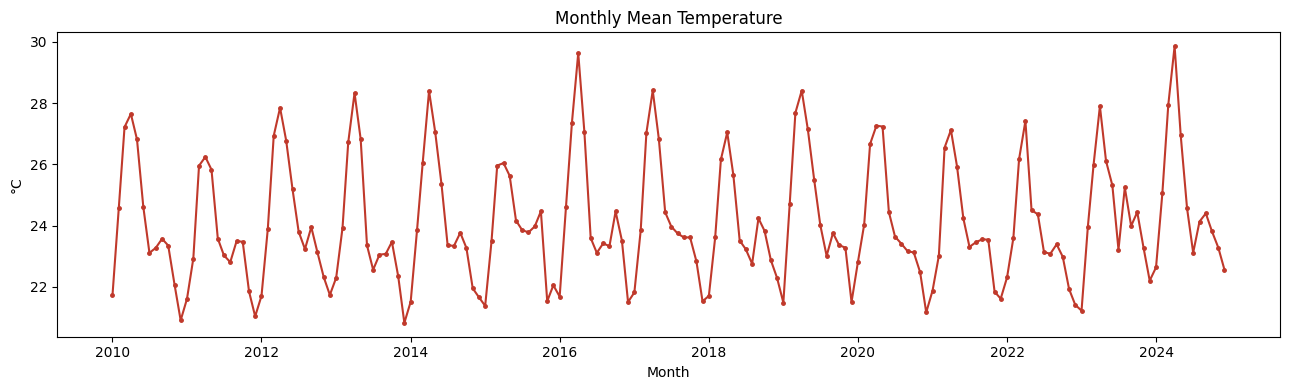

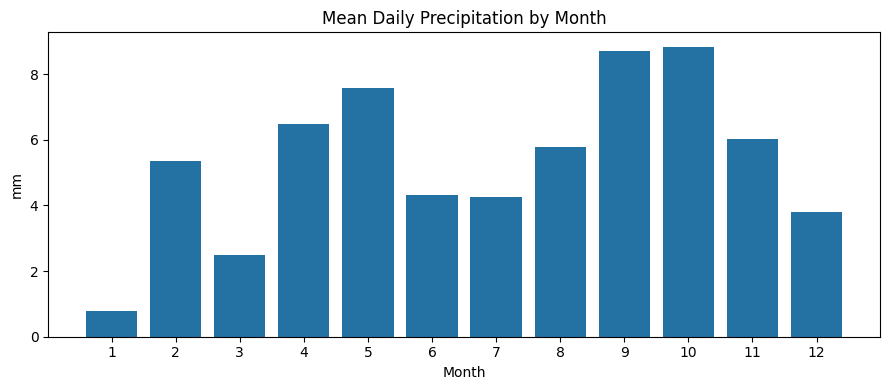

In [11]:
mt = temp.resample('MS').mean()
plt.figure(figsize=(13,4)); plt.plot(mt.index, mt.values, marker='o', ms=2.5, color='#c0392b')
plt.title('Monthly Mean Temperature'); plt.xlabel('Month'); plt.ylabel('°C'); plt.tight_layout(); plt.show()
clim = prcp.groupby(prcp.index.month).mean()
plt.figure(figsize=(9,4)); plt.bar(clim.index, clim.values, color='#2471a3')
plt.title('Mean Daily Precipitation by Month'); plt.xlabel('Month'); plt.ylabel('mm'); plt.xticks(range(1,13))
plt.tight_layout(); plt.show()

*Monthly means repeat the annual cycle (Apr/May max); precipitation climatology peaks Sep–Oct, dry Dec–Feb.*

<Figure size 1100x400 with 0 Axes>

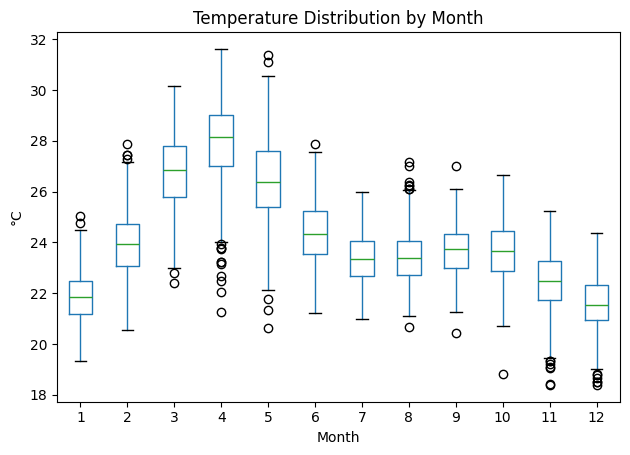

In [12]:
# Monthly boxplot + seasonal SUBSERIES plot
tdf = temp.to_frame('t'); tdf['month'] = tdf.index.month
plt.figure(figsize=(11,4)); tdf.boxplot(column='t', by='month', grid=False)
plt.title('Temperature Distribution by Month'); plt.suptitle(''); plt.xlabel('Month'); plt.ylabel('°C')
plt.tight_layout(); plt.show()

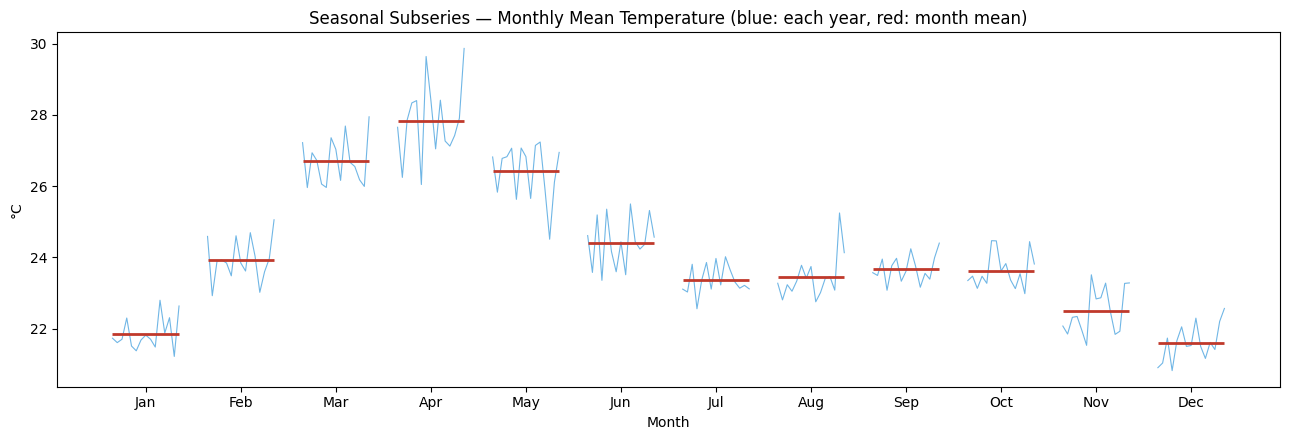

In [13]:
piv = temp.groupby([temp.index.year, temp.index.month]).mean().unstack(0)
mm = piv.mean(axis=1)
plt.figure(figsize=(13,4.5))
for i,m in enumerate(range(1,13)):
    xs = i + np.linspace(-0.35,0.35,len(piv.columns))
    plt.plot(xs, piv.loc[m].values, color='#3498db', lw=0.8, alpha=0.7)
    plt.hlines(mm.loc[m], i-0.35, i+0.35, color='#c0392b', lw=2)
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Seasonal Subseries — Monthly Mean Temperature (blue: each year, red: month mean)')
plt.xlabel('Month'); plt.ylabel('°C'); plt.tight_layout(); plt.show()

*The boxplot shows the seasonal location shift and wider pre-monsoon spread; the subseries plot shows each year's monthly means cluster tightly around the month mean — a **stable, repeatable** annual shape.*

## 5. Trend Analysis

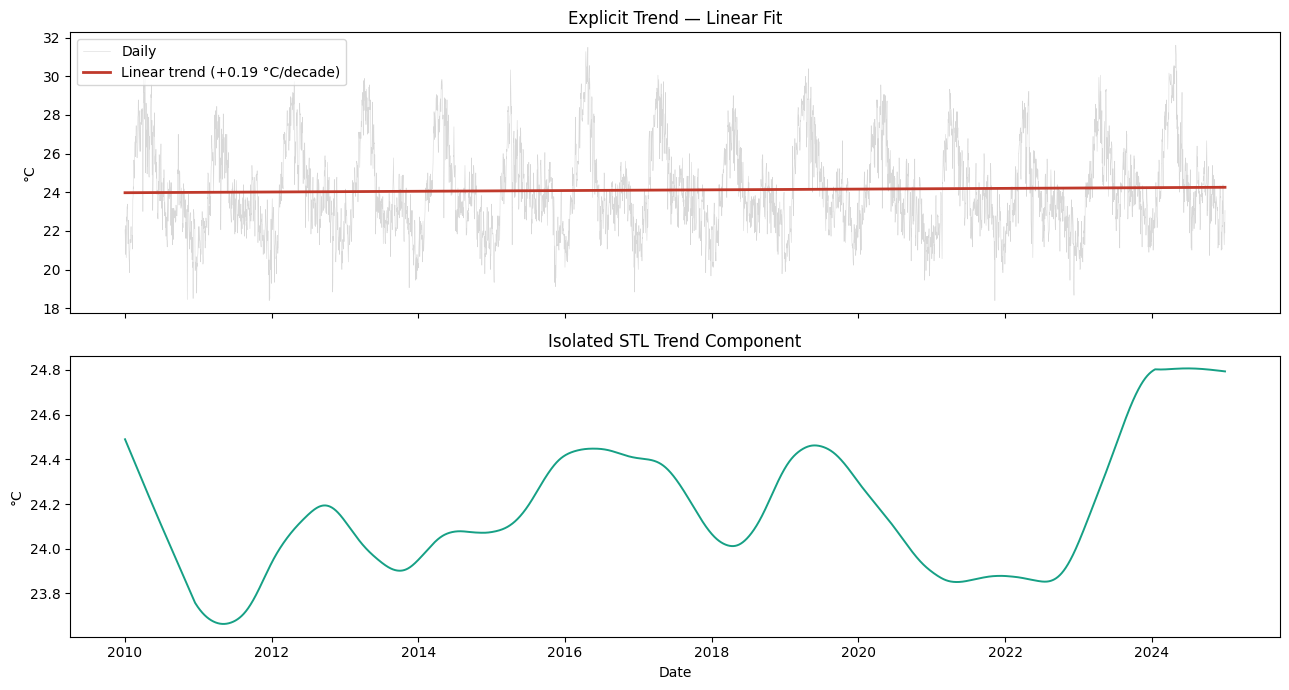

STL trend: 24.49 -> 24.79 °C (delta +0.30 °C)
Linear slope: +0.187 °C/decade | STL trend strength: 0.122


In [14]:
stl = STL(temp, period=365, robust=True).fit()
x = np.arange(len(temp)); slope, intercept = np.polyfit(x, temp.values, 1)
slope_dec = slope*365.25*10
ts = max(0.0, 1 - stl.resid.var()/(stl.trend+stl.resid).var())
fig, ax = plt.subplots(2,1,figsize=(13,7),sharex=True)
ax[0].plot(temp.index, temp.values, lw=0.4, alpha=0.3, color='grey', label='Daily')
ax[0].plot(temp.index, intercept+slope*x, lw=2, color='#c0392b', label=f'Linear trend ({slope_dec:+.2f} °C/decade)')
ax[0].legend(); ax[0].set_ylabel('°C'); ax[0].set_title('Explicit Trend — Linear Fit')
ax[1].plot(stl.trend.index, stl.trend.values, lw=1.4, color='#16a085')
ax[1].set_title('Isolated STL Trend Component'); ax[1].set_ylabel('°C'); ax[1].set_xlabel('Date')
plt.tight_layout(); plt.show()
print(f'STL trend: {stl.trend.dropna().iloc[0]:.2f} -> {stl.trend.dropna().iloc[-1]:.2f} °C '
      f'(delta {stl.trend.dropna().iloc[-1]-stl.trend.dropna().iloc[0]:+.2f} °C)')
print(f'Linear slope: {slope_dec:+.3f} °C/decade | STL trend strength: {ts:.3f}')

*A **mild warming trend** (~+0.19 °C/decade, +0.30 °C over 15 years) but **weak**
(trend strength 0.12) relative to the ~13 °C seasonal amplitude — the series is
season-dominated. This is an **observed** association over one station, **not** a
causal climate-change claim.*

## 6. Seasonality Analysis

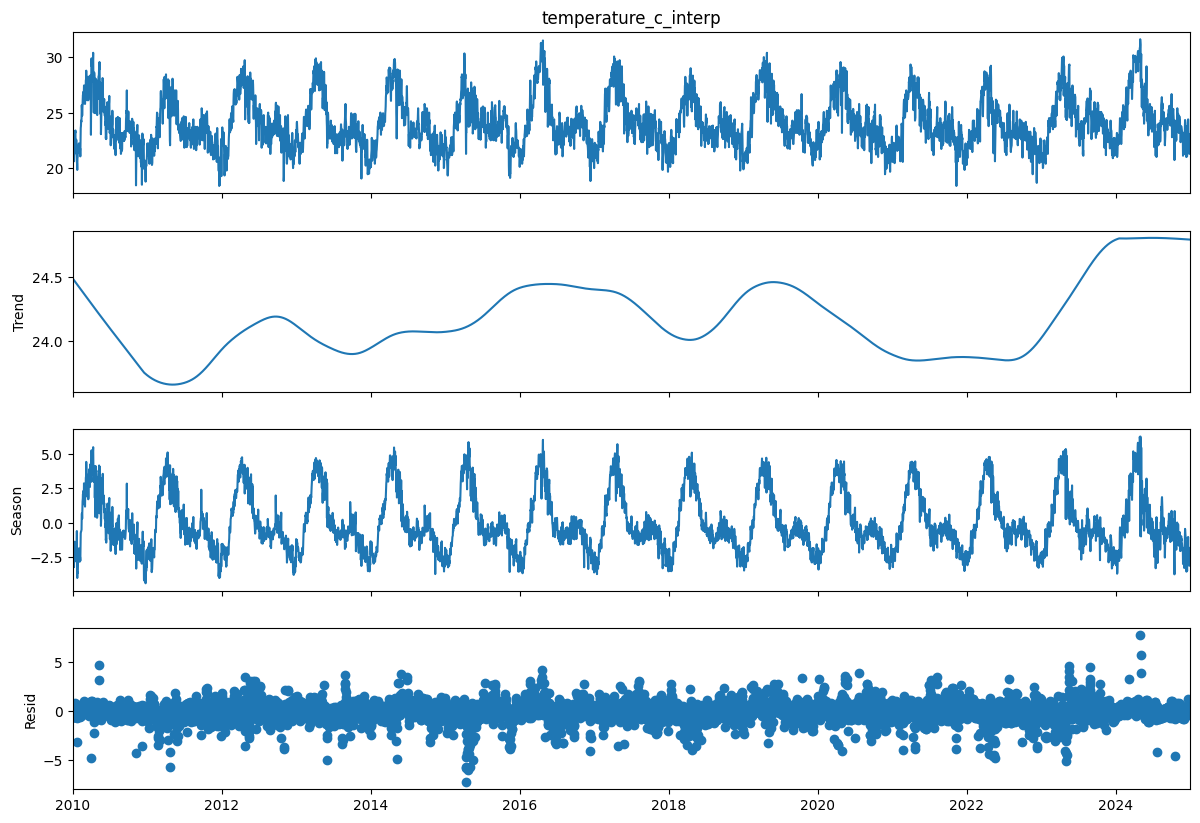

Seasonal strength: 0.800 | ACF at lag 365: 0.717


In [15]:
ss = max(0.0, 1 - stl.resid.var()/(stl.seasonal+stl.resid).var())
fig = stl.plot(); fig.set_size_inches(13,9); plt.show()
print(f'Seasonal strength: {ss:.3f} | ACF at lag 365: {temp.autocorr(365):.3f}')

*Seasonality is the within-year cycle driven by the solar year and monsoon (hot dry
Mar–May; cooler wet Jun–Sep; mild Oct–Feb). **Seasonal strength 0.80** (dominant), the
subseries plot shows it is **regular and annual**, and the **lag-365 ACF 0.717** is
direct autocorrelation evidence. Precipitation is seasonal only in monthly aggregate,
bursty day-to-day. This strong regular seasonality + high persistence is what makes
recent history predictive.*

## 7. Stationarity Analysis
**ADF** H0: unit root (non-stationary) → reject (p<0.05) ⇒ stationary.
**KPSS** H0: (level-)stationary → fail to reject (p≥0.05) ⇒ stationary. Opposite nulls.

In [16]:
td = temp.diff().dropna()
rows=[]
for name, s in [('Raw temperature', temp), ('First difference', td)]:
    a, k = S.adf_test(s), S.kpss_test(s)
    rows.append({'Series':name,'ADF stat':round(a['statistic'],3),'ADF p':round(a['p_value'],5),
                 'KPSS stat':round(k['statistic'],3),'KPSS p':k['p_value'],
                 'Conclusion':S.stationarity_conclusion(a,k)})
pd.DataFrame(rows)

,Series,ADF stat,ADF p,KPSS stat,KPSS p,Conclusion
0,Raw temperature,-5.825,0.0,0.044,0.1,Stationary (ADF & KPSS agree)
1,First difference,-24.462,0.0,0.022,0.1,Stationary (ADF & KPSS agree)


*Raw temperature is **stationary by both tests** — Bengaluru's bounded tropical
climate is mean-reverting despite seasonality. **Differencing** is examined as the
standard unit-root remedy: it keeps the series stationary and collapses lag-1 ACF from
0.92 to −0.15, but since the level series is already stationary, **differencing is not
required** (we model the level, whose persistence is the signal). **Transformation:**
we do **not** log-transform temperature (bounded, near-symmetric °C — a log is
meaningless); precipitation's right-skew would warrant `log1p` only if it were the target.*

## 8. ACF / PACF Analysis

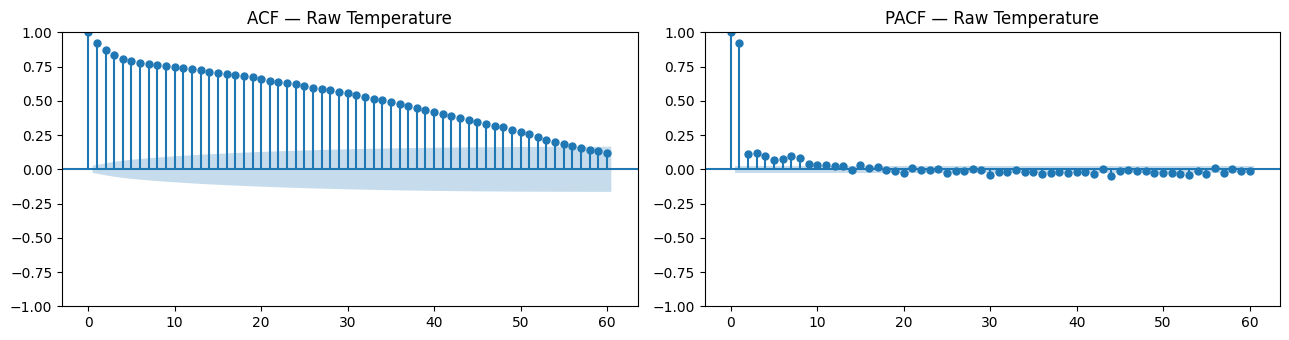

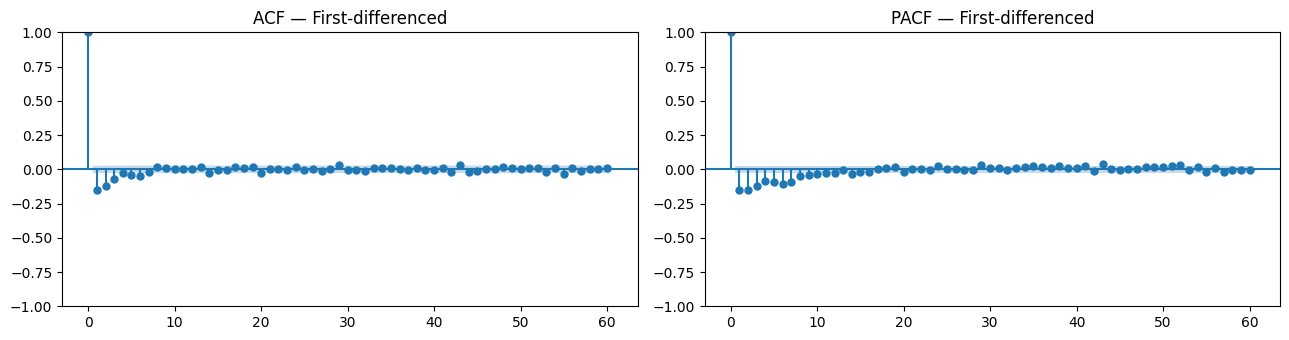

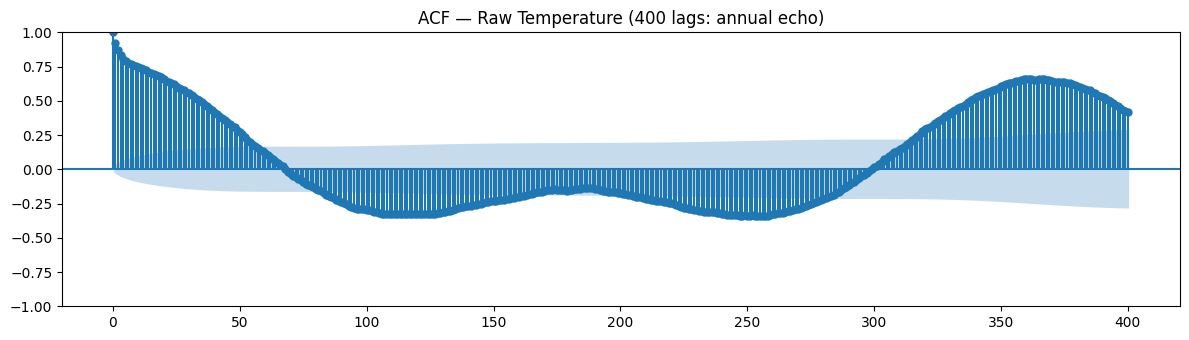

lag-1 ACF raw : 0.923
lag-7 ACF raw : 0.768
lag-365 ACF   : 0.717
lag-1 ACF diff: -0.15


In [17]:
for s, ttl in [(temp,'Raw Temperature'), (td,'First-differenced')]:
    fig, ax = plt.subplots(1,2,figsize=(13,3.5))
    plot_acf(s.dropna(), lags=60, ax=ax[0]); ax[0].set_title(f'ACF — {ttl}')
    plot_pacf(s.dropna(), lags=60, ax=ax[1], method='ywm'); ax[1].set_title(f'PACF — {ttl}')
    plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(12,3.5)); plot_acf(temp.dropna(), lags=400, ax=ax)
ax.set_title('ACF — Raw Temperature (400 lags: annual echo)'); plt.tight_layout(); plt.show()
print('lag-1 ACF raw :', round(temp.autocorr(1),3))
print('lag-7 ACF raw :', round(temp.autocorr(7),3))
print('lag-365 ACF   :', round(temp.autocorr(365),3))
print('lag-1 ACF diff:', round(td.autocorr(1),3))

*ACF measures total correlation across lags (incl. indirect); PACF isolates a lag
after removing shorter ones; the blue band is the ~95% confidence interval. Raw lag-1 =
0.923 (strong persistence), PACF cuts off after 1–2 lags (**AR-like**), annual echo at
lag-365 = 0.717. Differencing drops lag-1 to −0.150 (short-memory noise). → this
justifies a low-order **ARIMA(2,0,2)** (d=0, already stationary) and a **30-day input
window** for the neural models; persistence is expected to be a strong short-horizon baseline.*

## 9. Initial Findings and Research Hypothesis
Daily temperature at Bengaluru is a **strongly seasonal, highly persistent,
level-stationary** series with a **weak warming trend** (+0.30 °C/15 yr). STL assigns
most variation to a dominant annual cycle (strength 0.80); ADF (p≈0) and KPSS (p≥0.10)
agree the level is stationary, so differencing is unnecessary. The decisive forecasting
clue is the autocorrelation: lag-1 ACF 0.923 with an AR-like PACF means *yesterday
carries most of tomorrow's information*, and a lag-365 echo (0.717) encodes seasonality.
Precipitation is intermittent and near-unpredictable day-to-day — hence temperature is
the target.

**H1:** sequence models using recent history should beat naive mean/seasonal baselines
and can match or beat persistence given enough data.
**H0 (null):** deep-learning structure gives no material gain over naive persistence at
short horizons.

**Outcome (§10–16):** with 15 years of data the evidence **supports H1 and rejects H0** —
LSTM (0.650) and Transformer (0.655) both beat persistence (0.668), ARIMA is best (0.638),
and the Transformer dominates the 30-day horizon. (An earlier 6-year run could *not*
reject H0 — evidence that sample size, not model choice alone, decides whether deep
learning helps.)

## 10. Forecasting Methodology
Target: next-day temp (°C, t+1) plus multi-horizon t+1…t+30. Chronological **70/15/15**
split (no shuffling), scaler fit on **train only**, 30-day window, seed 42. Sequences
never contain their own target; test data are used neither for training nor
early-stopping — all metrics are **out-of-sample test** metrics.

In [18]:
print('Split:', RES['forecast_setup']['split'])
print('Train/Val/Test one-step sequences:',
      RES['forecast_setup']['n_train_seq'], RES['forecast_setup']['n_val_seq'], RES['forecast_setup']['n_test_seq'])
print('Test period:', RES['forecast_setup']['test_start'], '->', RES['forecast_setup']['test_end'])

Split: 70/15/15 chronological
Train/Val/Test one-step sequences: 3805 822 822
Test period: 2022-10-02 -> 2024-12-31


## 11. Baseline Models
Five baselines: **Persistence (t-1)** `ŷ(t+1)=y(t)` (no training; motivated by the high
ACF), **Seasonal naive (t-7)** and **(t-365)**, **Mean (climatology)**, and a classical
**ARIMA(2,0,2)** rolled one-step over the test set (d=0 since stationary).

In [19]:
b = RES['onestep']['baselines']
pd.DataFrame([{'Model':k,'MAE':round(v['mae'],3),'RMSE':round(v['rmse'],3)} for k,v in b.items()])

,Model,MAE,RMSE
0,Persistence (t-1),0.668,0.874
1,Seasonal naive (t-7),1.192,1.514
2,Seasonal naive (t-365),1.384,1.770
3,Mean (climatology),1.745,2.304
4,"ARIMA(2, 0, 2)",0.638,0.829


*Persistence is by far the strongest naive baseline; seasonal-naive and mean are much worse — a highly autocorrelated series is best approximated by its most recent value, not by last week/year or the long-run mean.*

## 12. LSTM
Recurrent gating suited to ordered sequences with strong recency. Architecture: input
(30×1) → LSTM(hidden 32, 1 layer) → linear head; MSE loss, Adam (1e-3), ≤15 epochs,
early stopping (patience 3), seed 42. Below we retrain the one-step LSTM live to show
convergence, then embed the saved forecast/loss/residual figures.

In [20]:
from sklearn.preprocessing import StandardScaler
vals = temp.values.astype(float); n=len(vals); SEQ=30
i_tr,i_va = int(n*0.70), int(n*0.85)
scaler = StandardScaler().fit(vals[:i_tr].reshape(-1,1))
scaled = scaler.transform(vals.reshape(-1,1)).ravel()
inv = lambda a: scaler.inverse_transform(np.asarray(a).reshape(-1,1)).ravel()
def one_step(a, lo, hi):
    X,y,idx=[],[],[]
    for t in range(SEQ,n):
        if lo<=t<hi: X.append(a[t-SEQ:t]); y.append(a[t]); idx.append(t)
    return np.array(X)[...,None], np.array(y), idx
Xtr,ytr,_ = one_step(scaled,SEQ,i_tr); Xva,yva,_ = one_step(scaled,i_tr,i_va); Xte,yte,ti = one_step(scaled,i_va,n)
yte_o = inv(yte); tdates = temp.index[ti]
lstm = M.LSTMForecaster(hidden=32, layers=1, horizon=1)
lstm, lv, ltt, lhist = M.train_model(lstm, Xtr,ytr,Xva,yva, epochs=15, patience=3)
pl = inv(M.predict(lstm, Xte).ravel())
print('LSTM (live)  MAE %.3f  RMSE %.3f  epochs %d  %.1fs'%(M.mae(yte_o,pl),M.rmse(yte_o,pl),len(lhist['train']),ltt))

LSTM (live)  MAE 0.650  RMSE 0.834  epochs 15  11.4s


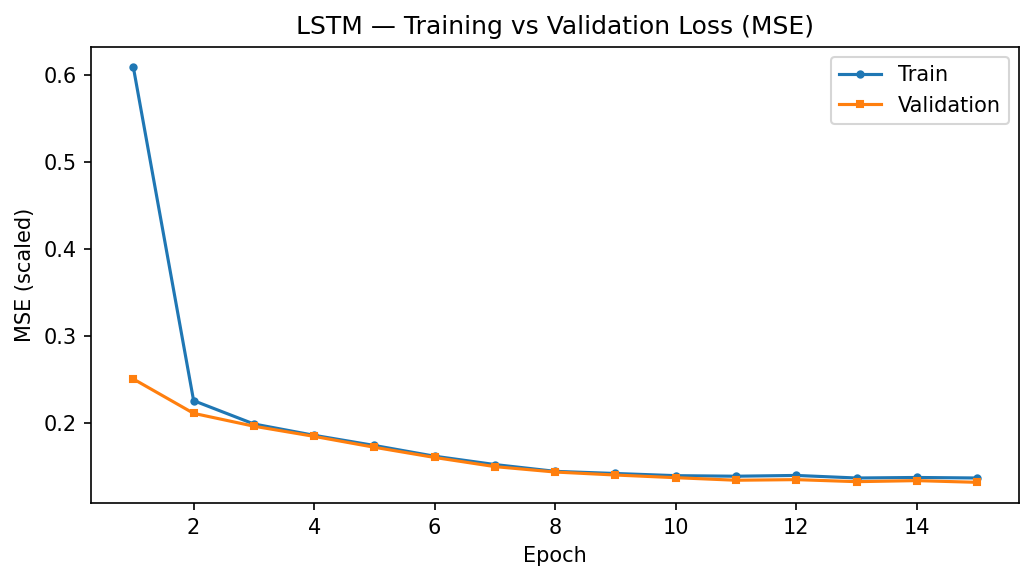

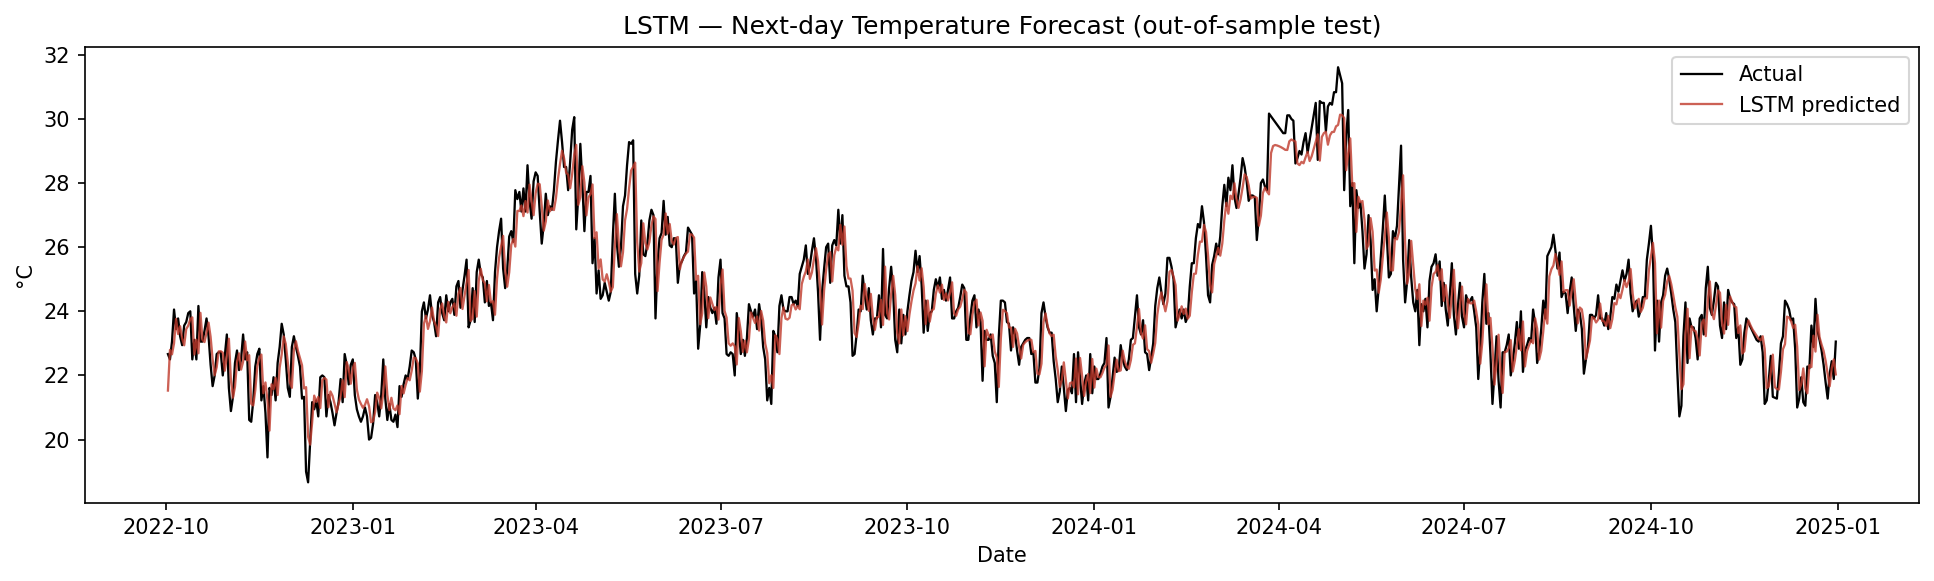

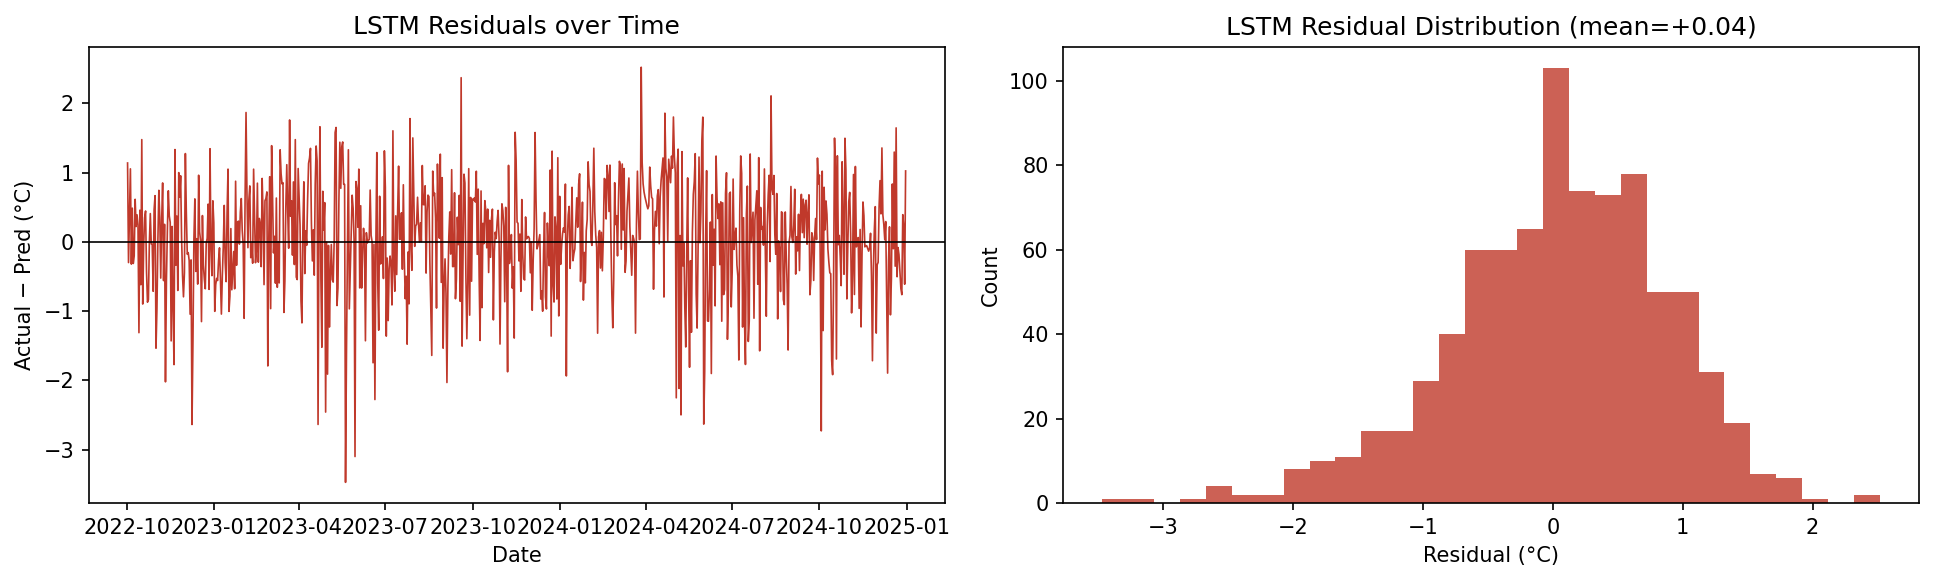

In [21]:
for f in ['lstm_loss.png','lstm_forecast.png','lstm_residuals.png']:
    display(Image(filename=os.path.join(FIG,f)))

*Smooth train/val convergence with early stopping (no overfitting); predictions track the seasonal signal; residuals are near-zero-mean and roughly symmetric.*

## 13. Transformer
Multi-head self-attention + sinusoidal positional encoding can attend to any lag in the
window (helpful at longer horizons). Architecture: input→linear(d_model 32)→PE→2
encoder layers (4 heads, ff 64, dropout 0.1)→head; same training recipe as the LSTM.

Transformer (live)  MAE 0.655  RMSE 0.837  epochs 8  19.4s


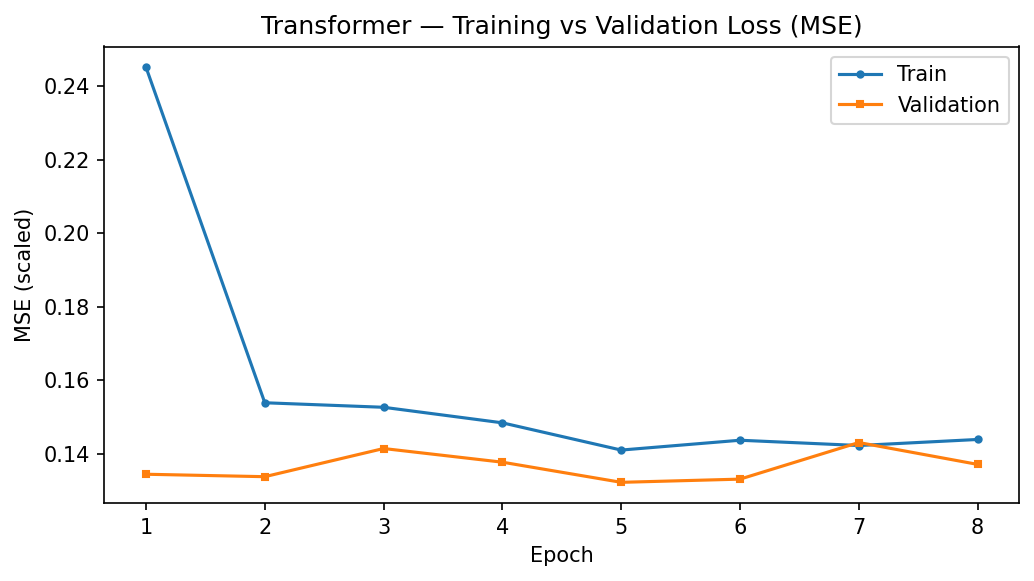

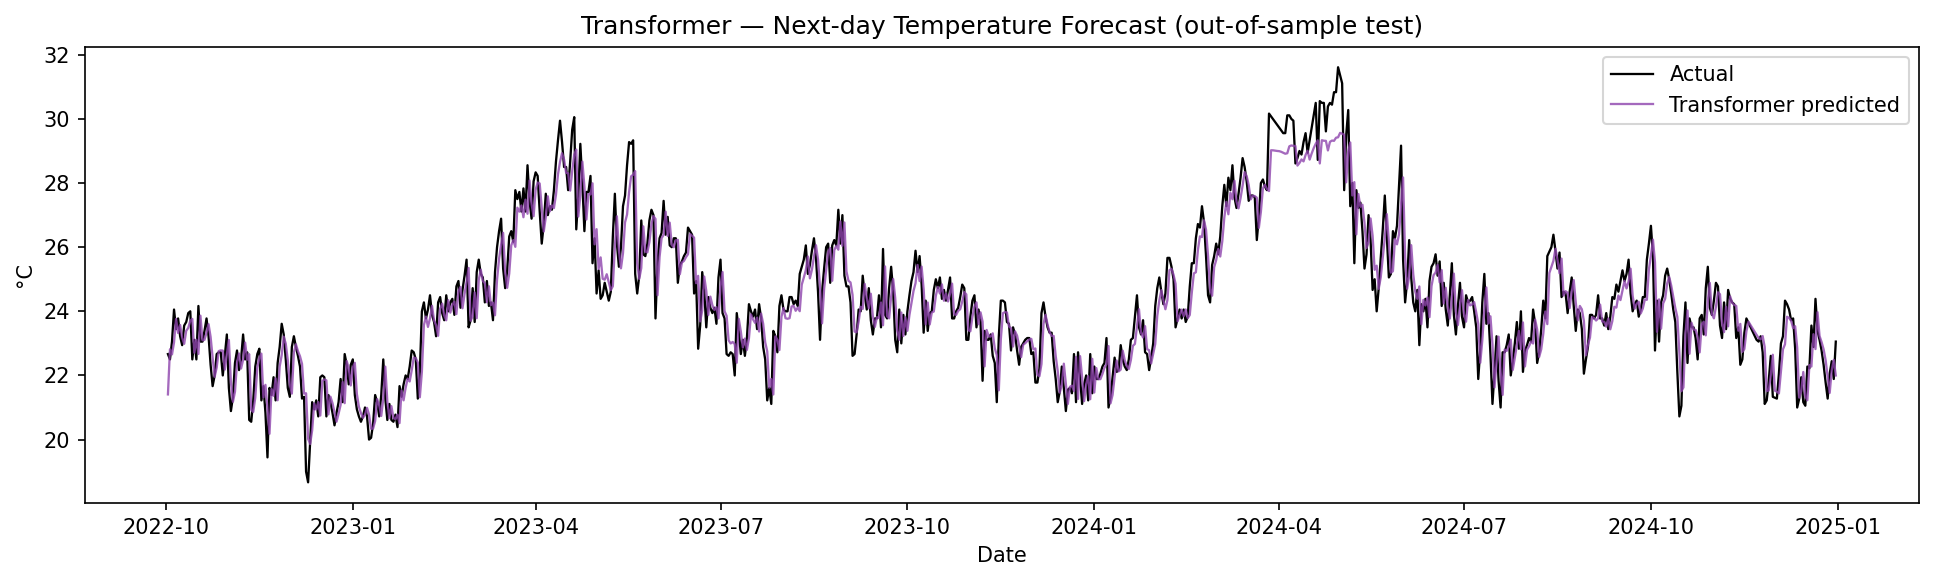

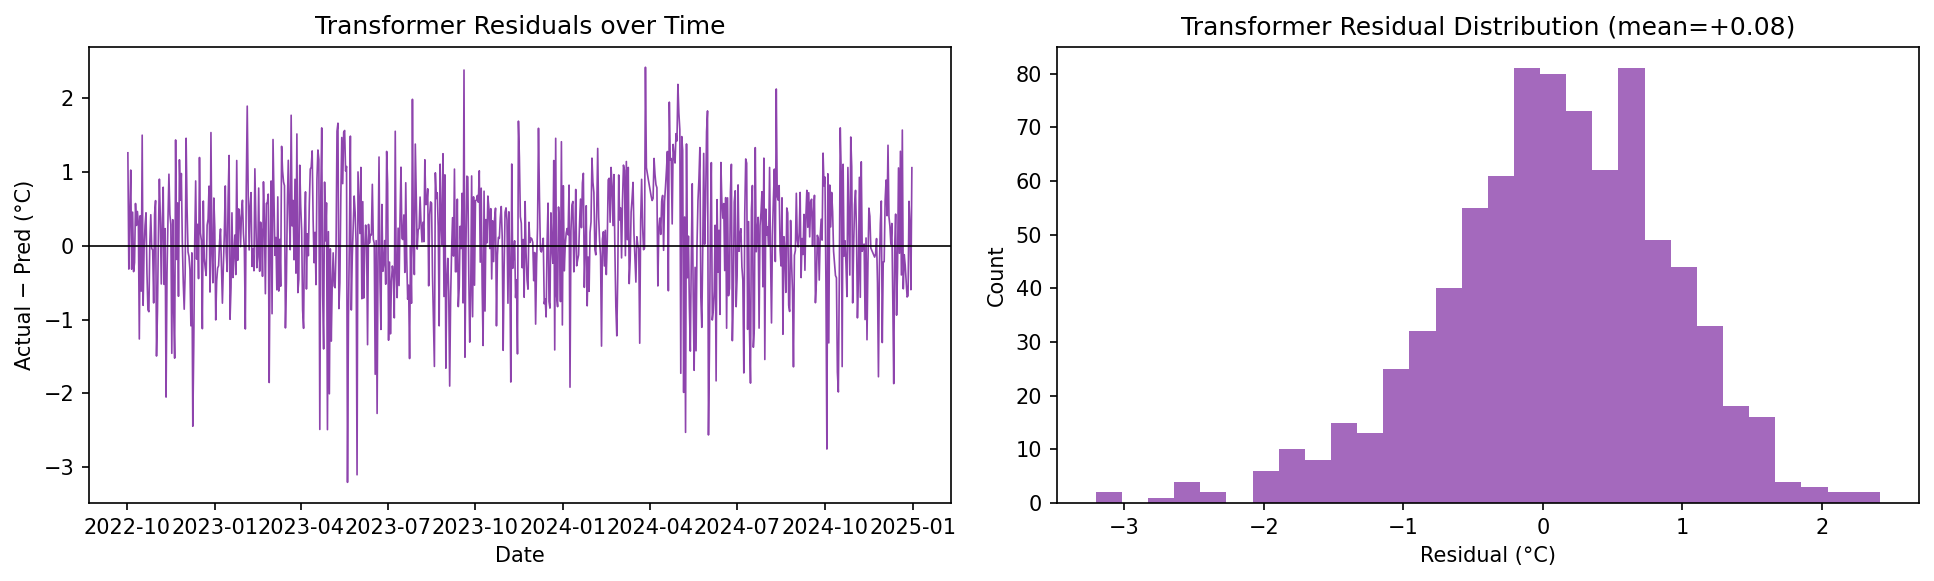

In [22]:
trf = M.TransformerForecaster(d_model=32,nhead=4,layers=2,ff=64,dropout=0.1,horizon=1)
trf, tv, ttt, thist = M.train_model(trf, Xtr,ytr,Xva,yva, epochs=15, patience=3)
pt = inv(M.predict(trf, Xte).ravel())
print('Transformer (live)  MAE %.3f  RMSE %.3f  epochs %d  %.1fs'%(M.mae(yte_o,pt),M.rmse(yte_o,pt),len(thist['train']),ttt))
for f in ['transformer_loss.png','transformer_forecast.png','transformer_residuals.png']:
    display(Image(filename=os.path.join(FIG,f)))

## 14. Test-Set Evaluation (leakage checks)
All metrics above/below are **out-of-sample** on the 822 test sequences spanning
2022-10-02 → 2024-12-31. Verified: scaler fit on train only; input windows exclude
their target; test data never used for training or early stopping; predictions inverted
back to °C and aligned to their true dates.

In [23]:
assert np.isclose(scaler.mean_[0], vals[:i_tr].mean())   # scaler used train stats only
assert min(ti) >= i_va and max(ti) < n                    # test targets in the test region
print('Leakage checks passed. Test target dates:', tdates.min().date(), '->', tdates.max().date())
print('N test sequences:', len(Xte))

Leakage checks passed. Test target dates: 2022-10-02 -> 2024-12-31
N test sequences: 822


## 15. Error / Residual Analysis & Spike Investigation

LSTM residual mean : +0.044 °C
Transformer resid. mean: +0.076 °C
Top-10 largest-error days shared by BOTH models: 10 of 10
Of those spike days, # with interpolated inputs: 0
Shared high-error dates: ['2022-12-09', '2023-04-21', '2023-04-29', '2023-05-20', '2023-05-30', '2023-09-19', '2024-03-27', '2024-05-08', '2024-06-01', '2024-10-03']


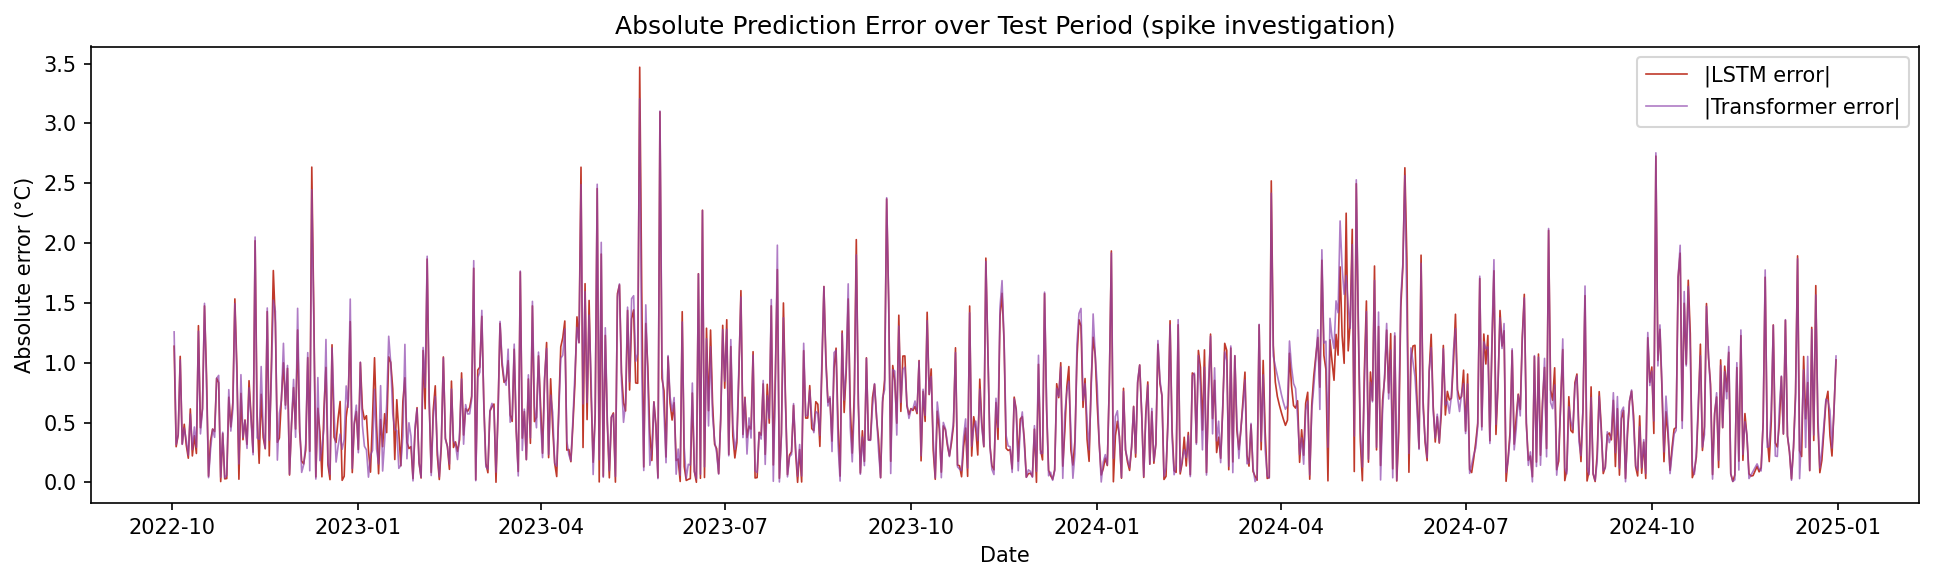

In [24]:
ea = RES['error_analysis']
print('LSTM residual mean : %+.3f °C'%ea['lstm_residual_mean'])
print('Transformer resid. mean: %+.3f °C'%ea['trf_residual_mean'])
print('Top-10 largest-error days shared by BOTH models:', ea['n_overlap'], 'of 10')
print('Of those spike days, # with interpolated inputs:', ea['spike_dates_interpolated'])
print('Shared high-error dates:', ea['top10_error_overlap_dates'])
display(Image(filename=os.path.join(FIG,'error_spikes.png')))

*All 10 largest-error days are **shared** by both models and **none** coincide with
interpolated inputs — they fall on abrupt pre-monsoon heat swings and monsoon-onset
transitions. The models share a genuine limitation (they lag rapid regime changes)
rather than suffering a data-quality artefact.*

## 16. Model Comparison

,Model,MAE,RMSE
0,"ARIMA(2, 0, 2)",0.638,0.829
1,LSTM,0.650,0.834
2,Transformer,0.655,0.837
3,Persistence (t-1),0.668,0.874
4,Seasonal naive (t-7),1.192,1.514
5,Seasonal naive (t-365),1.384,1.770
6,Mean (climatology),1.745,2.304


Best one-step model (lowest RMSE): ARIMA(2, 0, 2)


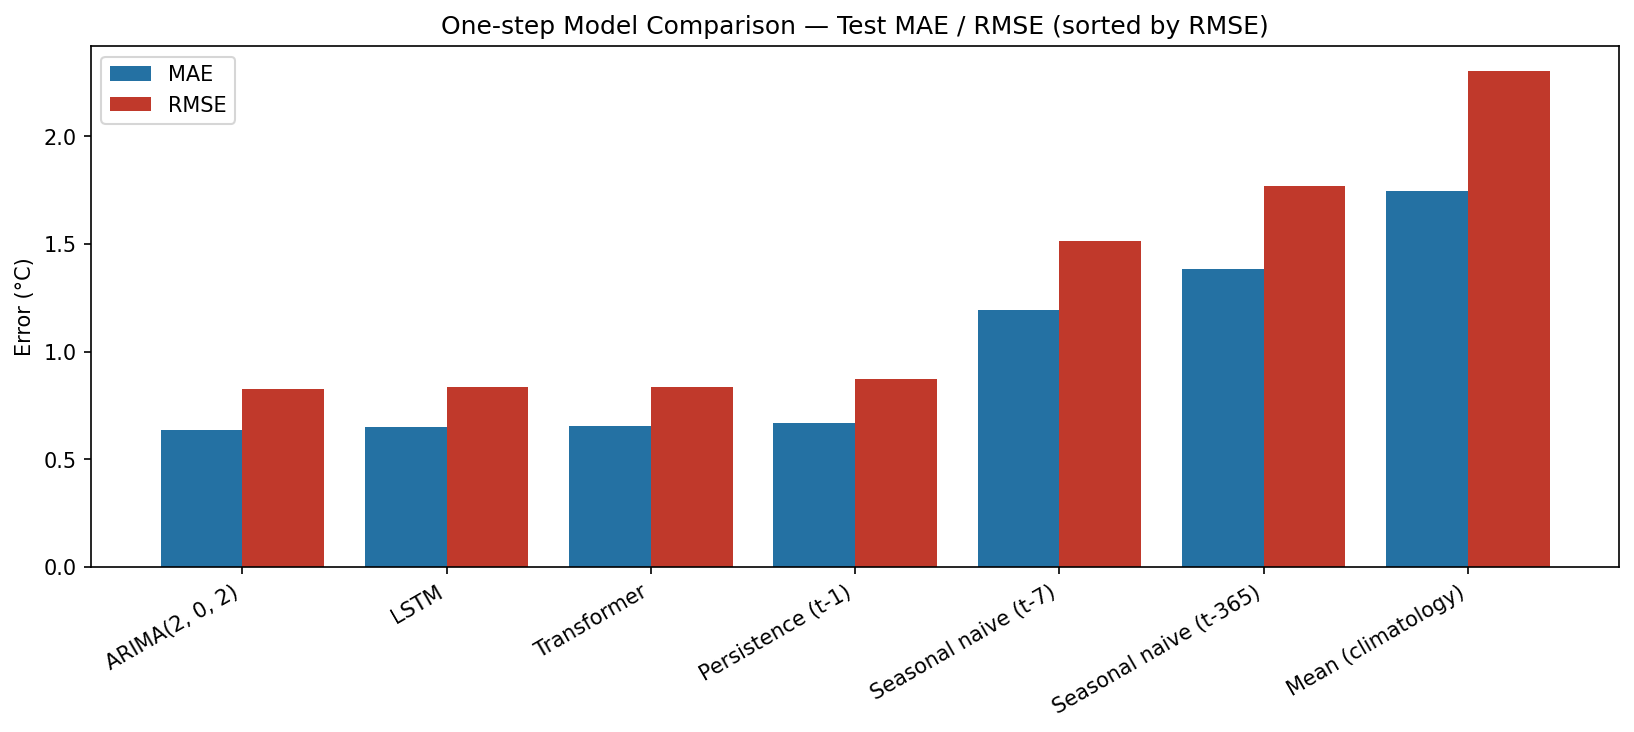

In [25]:
rank = RES['onestep']['ranking']
display(pd.DataFrame([{'Model':r['model'],'MAE':round(r['mae'],3),'RMSE':round(r['rmse'],3)} for r in rank]))
print('Best one-step model (lowest RMSE):', RES['onestep']['best'])
display(Image(filename=os.path.join(FIG,'model_comparison.png')))

**Multi-horizon MAE by lead time** — *which* model wins depends on horizon:

,Model,1d,7d,14d,21d,30d
0,Persistence,0.67,1.18,1.32,1.51,1.74
1,Seasonal naive (365),1.41,1.40,1.40,1.40,1.39
2,LSTM,0.82,1.03,1.19,1.36,1.49
3,Transformer,0.69,1.02,1.17,1.29,1.38


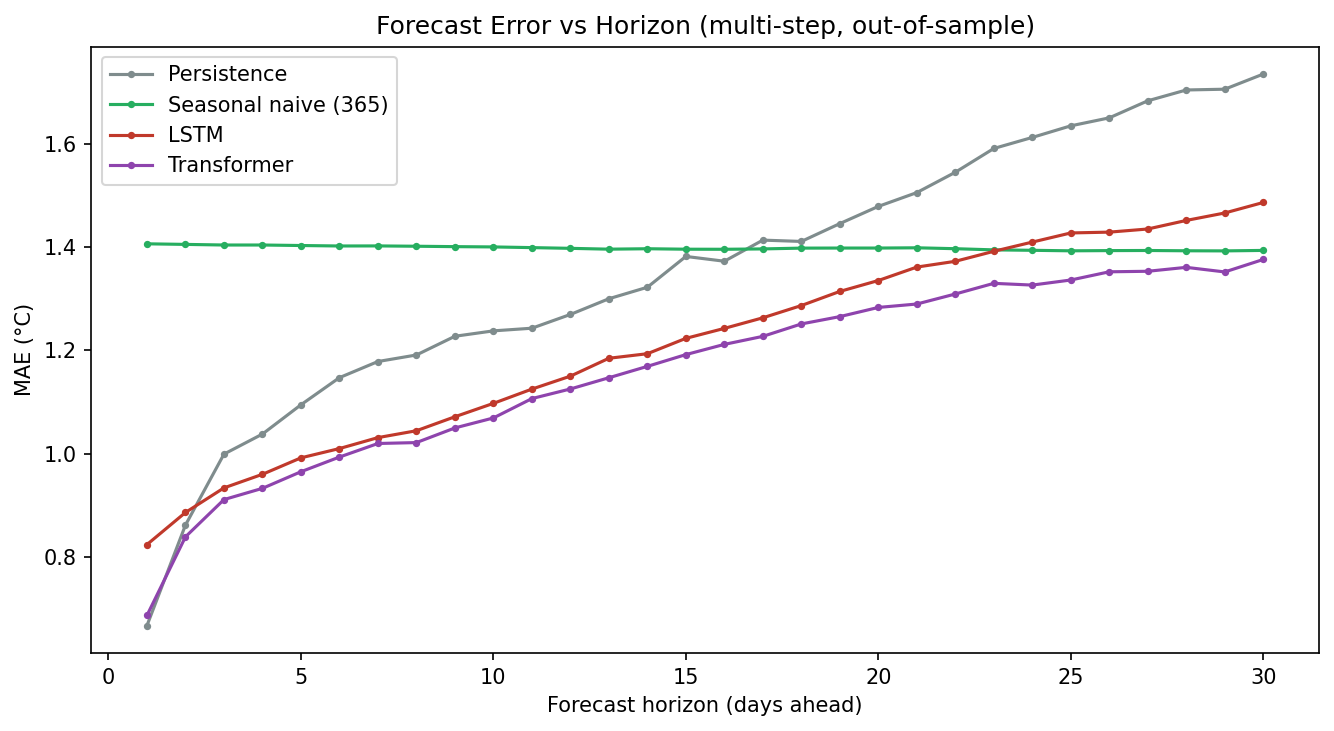

In [26]:
mh = RES['multi_horizon']; H = mh['horizons']
rows=[]
for m in ['Persistence','Seasonal naive (365)','LSTM','Transformer']:
    rows.append({'Model':m, **{f'{h}d':round(mh[m][str(h)]['mae'],2) for h in H}})
display(pd.DataFrame(rows))
display(Image(filename=os.path.join(FIG,'error_vs_horizon.png')))

*Lower is better. ARIMA/LSTM/Transformer all beat persistence at t+1 (rejecting H0);
persistence degrades fastest with lead time while the **Transformer degrades most
gracefully and is best from day 7 to day 30**. Seasonal-naive(365) is flat (copies last
year) and only competitive past ~3 weeks. Small differences among the top models are not
claimed statistically significant.*

## 17. Limitations
Single station/location; 15 years is short for climate-trend attribution; GSOD daily
precipitation has substantial documented missingness; univariate (no exogenous
predictors such as humidity/pressure/rainfall); models intentionally tiny/untuned
(CPU/battery); single temporal holdout (no rolling-origin CV); the t+1 horizon
structurally favours persistence.

## 18. Conclusion
Bengaluru daily temperature (2010–2024) is a **stationary, strongly seasonal, highly
persistent** series with a weak warming trend (+0.19 °C/decade); precipitation is
intermittent and seasonal only in aggregate. The statistical evidence (STL, ADF/KPSS,
ACF/PACF) is internally consistent and drives the forecasting design. Answering the
research question: recent history is highly predictive, and **with adequate data the
LSTM and Transformer beat naive persistence at one step (H0 rejected), while the
Transformer is clearly best across a 30-day horizon**; a classical ARIMA is marginally
best at t+1. The models' shared weakness is anticipating abrupt seasonal-transition
swings — the natural next step is adding exogenous predictors and rolling-origin
evaluation.